#### LSTM (장기 의존성 학습 모델)
- RNN 구조에서 발생하는 문제를 해결하기 위해 구조를 변경한 모델 
- 기존의 RNN은 학습 횟수가 증가하면 과거의 기억을 잃는다. 
    - 반복 학습을 하면서 가중치의 변화량이 0에 가까워진다. 
    - 손실 함수 -> tanh -> 반복적으로 -1 ~ 1의 가중치의 변화량이 곱해지면서 0에 수렴 (기억 손실)
- LSTM 모델은 반복 학습을 하면서 과거의 기억 중 장기 기억과 단기 기억으로 나눠주는 역할
    - 반복 학습을 하면서 tanh() 중복적으로 실행하면서 기울기는 0에 가까워짐
    - 장기 기억 tanh() 함수를 실행하지 않는다. -> 가중치의 변화를 유지
    - cell 공간에 장기 기억 정보를 전달
    - 게이트로 정보를 선택적으로 보관, 삭제, 출력 

In [8]:
import pandas as pd 
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [57]:
# 하나의 함수화 생각하면서 코드를 작성 
# 매개변수로 사용할 데이터를 어떤것들이 있을까?
# 파일의 경로를 지정하는 변수  (read_csv)
file_path = '../csv/aapl.csv'
# 구간(window) 설정 ( Dataset )
window = 60
# 배치 사이즈 지정 (DataLoader)
x_batch = 64
y_batch = 256
# 기여도 (optimizer)
lr = 0.001
# 반복 학습의 횟수
epochs = 20
# 은닉층에서의 뉴런(피쳐)의 개수
hidden_cnt = 64
# Layer 설정 값
layer_cnt = 1
# train, test 비율
train_ratio = 0.8
# 은닉층, 셀 구조에서 어떤 부분을 사용할것인가?
# 'h', 'c', 'h_c'
head_type = 'h_c'


In [58]:
df = pd.read_csv(file_path)
# 결측치 제거 (주식 데이터에서 결측치는 개수가 1개뿐, 결측치가 존재하면 안되는 데이터셋이기때문에 제거)
df.dropna(inplace=True)

In [59]:
# Date 컬럼을 시계열 데이터로 변환
# 그래프 시각화할때 x축으로 사용하기 위함
df['Date'] = pd.to_datetime(df['Date'])
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.410525,117258400.0
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.389106,43971200.0
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.360548,26432000.0
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.369472,21610400.0
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.380182,18362400.0


In [60]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
9710,2019-06-18,196.050003,200.289993,195.210007,198.449997,198.449997,26551000.0
9711,2019-06-19,199.679993,199.880005,197.309998,197.869995,197.869995,21124200.0
9712,2019-06-20,200.369995,200.610001,198.029999,199.460007,199.460007,21514000.0
9713,2019-06-21,198.800003,200.850006,198.149994,198.779999,198.779999,47735300.0
9714,2019-06-24,198.539993,200.160004,198.169998,199.169998,199.169998,9025362.0


In [61]:
# 독립, 종속 데이터로 분할 
x = df[['Adj Close', 'Volume']].astype(float).values
y = df[['Adj Close']].astype(float).values

In [62]:
# train, test 데이터셋
X_train, X_test, y_train, y_test = train_test_split(
    x, y, train_size=train_ratio, shuffle=False
)

In [63]:
X_train[-5:]

array([[5.0455521e+01, 2.0321910e+08],
       [4.9966183e+01, 1.5812440e+08],
       [4.9684608e+01, 1.0740940e+08],
       [4.8878670e+01, 1.6277170e+08],
       [4.7721058e+01, 1.3691020e+08]])

In [64]:
# train_test_split() 함수와 결과가 같은지 비교
split_idx = int(len(x) * train_ratio)
X_train2 = x[:split_idx]
X_train2[-5:]

array([[5.0455521e+01, 2.0321910e+08],
       [4.9966183e+01, 1.5812440e+08],
       [4.9684608e+01, 1.0740940e+08],
       [4.8878670e+01, 1.6277170e+08],
       [4.7721058e+01, 1.3691020e+08]])

#### 연습 
1. DataSet를 생성 -> 입력 데이터는 array의 형태이며 출력은 tensor 형태로 구성 
    - tensor를 생성하는 과정에서는 깊은 복사를 이용한 원본의 데이터를 유지하도록 생성 
    - window 값에 따라서 구간을 설정하는 방법 
2. MinMaxScaler를 이용하여 데이터를 스케일링
3. Dataset에 데이터를 입력 ( 초기에 설정한 window 값 사용 )
4. DataLoader를 이용하여 train_dl, test_dl을 생성 
    - train DataLoader는 x_batch를 이용
    - test DataLoader는 y_batch를 이용

In [65]:
class windowDS(Dataset):
    def __init__(self, _x, _y, _window):
        self.x = _x
        self.y = _y
        self.window = _window
        self.n = len(_x) - _window

    def __len__(self):
        return max(self.n, 1)
    
    def __getitem__(self, idx):
        x = self.x[idx : idx + self.window]
        y = self.y[idx + self.window]
        # 깊은 복사로 tensor 생성 
        # 일반적으로 얕은 복사를 사용하는 경우가 많음 :  메모리의 사용량 줄이기
        x_tensor = torch.tensor(x, dtype = torch.float32)
        y_tensor = torch.tensor(y, dtype = torch.float32)
        return x_tensor, y_tensor

In [66]:
# 스케일링 작업 
x_scaler = MinMaxScaler().fit(X_train)
y_scaler = MinMaxScaler().fit(y_train)

X_train_sc = x_scaler.transform(X_train)
X_test_sc = x_scaler.transform(X_test)
y_train_sc = y_scaler.transform(y_train)
y_test_sc = y_scaler.transform(y_test)

In [67]:
# 데이터셋 생성 
train_ds = windowDS(X_train_sc, y_train_sc, window)
test_ds = windowDS(X_test_sc, y_test_sc, window)

In [68]:
import random

In [69]:
for i in range(2):
    idx = random.choice(range(len(train_ds)))
    print(train_ds[idx])

(tensor([[0.0164, 0.0216],
        [0.0167, 0.0287],
        [0.0158, 0.0264],
        [0.0153, 0.0366],
        [0.0164, 0.0355],
        [0.0158, 0.0194],
        [0.0161, 0.0188],
        [0.0162, 0.0227],
        [0.0163, 0.0148],
        [0.0155, 0.0242],
        [0.0158, 0.0160],
        [0.0162, 0.0155],
        [0.0162, 0.0192],
        [0.0160, 0.0156],
        [0.0164, 0.0158],
        [0.0168, 0.0135],
        [0.0166, 0.0098],
        [0.0158, 0.0419],
        [0.0157, 0.0250],
        [0.0164, 0.0225],
        [0.0162, 0.0099],
        [0.0165, 0.0136],
        [0.0164, 0.0128],
        [0.0164, 0.0130],
        [0.0161, 0.0170],
        [0.0160, 0.0164],
        [0.0163, 0.0235],
        [0.0157, 0.0261],
        [0.0159, 0.0200],
        [0.0163, 0.0105],
        [0.0160, 0.0098],
        [0.0163, 0.0145],
        [0.0164, 0.0273],
        [0.0161, 0.0139],
        [0.0166, 0.0244],
        [0.0170, 0.0208],
        [0.0171, 0.0273],
        [0.0178, 0.0300],
        [0.

In [70]:
# DataLoader 생성 
train_dl = DataLoader(train_ds, shuffle = True, drop_last=True, batch_size=x_batch)
test_dl = DataLoader(test_ds, shuffle=False, drop_last=False, batch_size=y_batch)

In [71]:
# LSTM 모델의 정의 
class LSTMModel(nn.Module):

    def __init__(
            self, 
            input_size, 
            hidden_size = 64, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            batch_first = True, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()

        # LSTM 기본 설정 
        self.lstm = nn.LSTM(
            input_size = input_size, 
            hidden_size= hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first=batch_first
        )

        # budirectional 이 True면 아웃 피쳐의 개수가 2배 
        hidden_size = hidden_size * (2 if bidirectional else 1)

        # head_type에 따라서 출력의 피쳐 개수가 달라진다. 
        if head_type in ['h', 'c']:
        # if (head_type == 'f') | (head_type == 'c'):
            pass
        elif head_type == 'h_c':
            hidden_size = hidden_size * 2
        else:
            print("head_type의 인자의 값을 잘못 입력하였습니다 ('h', 'c', 'h_c')을 써주세요")

        # 선형 모델 생성
        self.model = nn.Linear(hidden_size, 1)
        # 객체 안에 독립적인 데이터를 저장
        self.head_type = head_type

    # 순전파 함수 정의 
    def forward(self, x):
        # 순전파의 예측 값 (RNN 모델에서는 2개 ,  LSTM 모델을 3개 )
        out, ( h_n, c_n ) = self.lstm(x)
        # 은닉층의 가장 마지막 값 저장 
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
            feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat( [h_last, c_last], dim=-1 )
        
        return self.model(feat)

In [72]:
# 모델을 생성 
model = LSTMModel(input_size=2, hidden_size= hidden_cnt, head_type= head_type)
model

LSTMModel(
  (lstm): LSTM(2, 64, batch_first=True)
  (model): Linear(in_features=128, out_features=1, bias=True)
)

In [73]:
# 손실 함수 
criterion = nn.MSELoss()
# 옵티마이저 설정 
optimizer = optim.Adam(model.parameters(), lr = lr)

In [74]:
# 검증 데이터의 loss 값 확인하는 함수 

@torch.no_grad()
def evaluate_mse(dl):
    model.eval()

    total_loss, total_n  = 0.0, 0
    # 데코레이터를 사용하지 않는 경우 with을 이용
    # with torch.no_grad():
    for x, y in dl:
        x = x.float()
        y = y.float()
        pred = model(x)
        loss = criterion(pred, y)
        total_loss += loss.item() * y.size(0)
        total_n += y.size(0)
    
    return total_loss / max(total_n, 1)

In [75]:
# 반복 학습 
test_history = []

for epoch in range(epochs):
    model.train()

    total_loss, total_n = 0.0, 0

    for x, y in train_dl:
        x = x.float()
        y = y.float()

        pred = model(x)
        loss = criterion(pred, y)       # 데이터들의 평균 오차 
        optimizer.zero_grad()
        loss.backward()
        # 기울기 발산 방지 
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
    
        total_loss += loss.item() * y.size(0)
        total_n += y.size(0)
    
    train_loss = total_loss / max(total_n, 1)

    test_loss = evaluate_mse(test_dl)

    test_history.append(test_loss)

    print(f"Epoch : {epoch + 1}, train_mse : {round(train_loss, 4)},\
           test_mse : {round(test_loss, 4)}")

Epoch : 1, train_mse : 0.0097,           test_mse : 0.1481
Epoch : 2, train_mse : 0.0001,           test_mse : 0.2425
Epoch : 3, train_mse : 0.0001,           test_mse : 0.3224
Epoch : 4, train_mse : 0.0001,           test_mse : 0.3022
Epoch : 5, train_mse : 0.0001,           test_mse : 0.2625
Epoch : 6, train_mse : 0.0001,           test_mse : 0.2121
Epoch : 7, train_mse : 0.0001,           test_mse : 0.2125
Epoch : 8, train_mse : 0.0001,           test_mse : 0.2068
Epoch : 9, train_mse : 0.0001,           test_mse : 0.1753
Epoch : 10, train_mse : 0.0001,           test_mse : 0.128
Epoch : 11, train_mse : 0.0001,           test_mse : 0.1636
Epoch : 12, train_mse : 0.0,           test_mse : 0.1137
Epoch : 13, train_mse : 0.0001,           test_mse : 0.0871
Epoch : 14, train_mse : 0.0001,           test_mse : 0.0945
Epoch : 15, train_mse : 0.0001,           test_mse : 0.0854
Epoch : 16, train_mse : 0.0,           test_mse : 0.0896
Epoch : 17, train_mse : 0.0,           test_mse : 0.0719

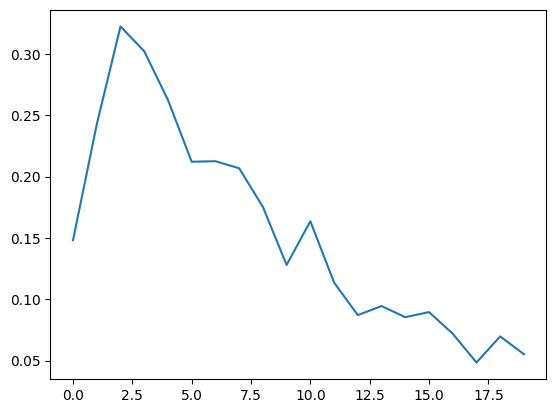

In [76]:
# test_hitory를 그래프 시각화
plt.plot(test_history)
plt.show()

In [77]:
# 예측값 생성 
model.eval()

preds, trues = [], []

with torch.no_grad():
    for x, y in test_dl:
        x = x.float()
        pred = model(x)
        preds.append(pred)
        trues.append(y)
# tensor 데이터들을 하나로 합쳐주고 차원을 벗어낸 다음 array로 변환 
preds = torch.cat(preds, dim=0).numpy()
trues = torch.cat(trues, dim=0).numpy()

# 스케일링 데이터 원본 데이터로 변환 
pred_origin = y_scaler.inverse_transform(preds).squeeze(-1)
true_origin = y_scaler.inverse_transform(trues).squeeze(-1)

In [78]:
pred_origin

array([ 50.00231 ,  50.24049 ,  50.459103, ..., 170.20753 , 171.03654 ,
       171.4399  ], shape=(1883,), dtype=float32)

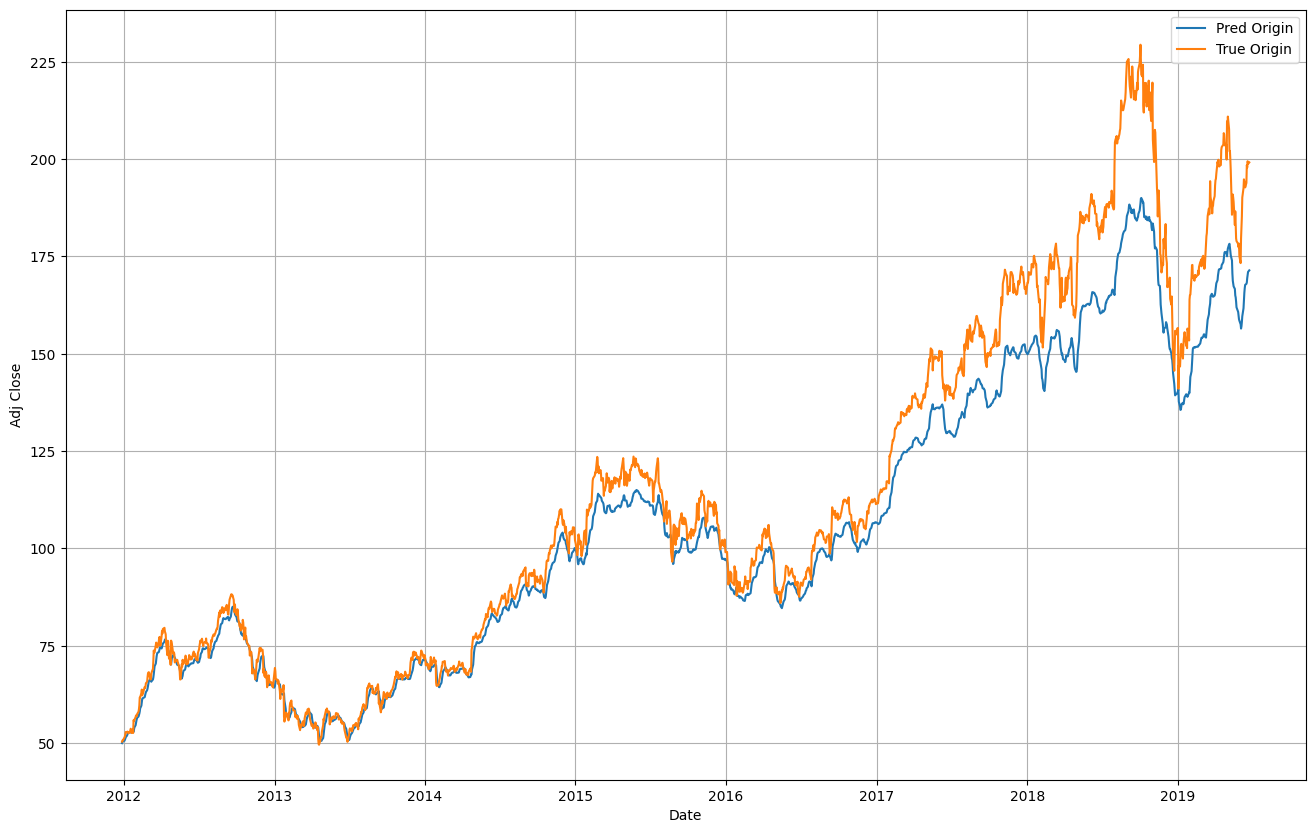

In [79]:
split_idx = int(len(df) * train_ratio)
# test_data에서 window(60일) 지난 61일차의 날짜부터 
x_data = df['Date'].values[split_idx + window :]

plt.figure(figsize=(16, 10))
plt.plot(x_data, pred_origin, label = 'Pred Origin')
plt.plot(x_data, true_origin, label = 'True Origin')

plt.legend()
plt.grid()
plt.xlabel("Date")
plt.ylabel('Adj Close')

plt.show()
